<a href="https://colab.research.google.com/github/Yukta30/BiometricSecuritywithAIBackDoorTargetedAttacks/blob/main/CS228BackdoorTargetedAttacks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS228 — Biometric Security with AI
## Project Checkpoint 1
*Topic:* Backdoor Poisoning Attack on Face Recognition

Dataset: CASIA-WebFace (subset of 150 identities)

Model: ResNet-50 baseline classifier

Author: Yukta Vajpayee

Due: March 30, 2026

In [ ]:
# ─────────────────────────────────────────
# CELL 2 — Install required libraries
# ─────────────────────────────────────────
!pip install numpy==1.24.3 -q --force-reinstall
!pip install torch torchvision timm tqdm scikit-learn matplotlib pillow -q

print("✅ All libraries installed")
print("⚠️  Now click: Runtime → Restart Session")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 70.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
✅ All libraries installed
⚠️  Now click: Runtime → Restart Session


In [ ]:
# ─────────────────────────────────────────
# CELL 3 — Imports
# ─────────────────────────────────────────
import os
import random
import struct
import io
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✅ All imports successful")
print(f"✅ Device : {device}")
if device.type == 'cuda':
    print(f"   GPU   : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM  : "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

✅ All imports successful
✅ Device : cuda
   GPU   : Tesla T4
   VRAM  : 15.6 GB


In [ ]:
# ─────────────────────────────────────────
# CELL 4 — Mount Google Drive
# ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Set base path to your dataset folder
BASE = '/content/drive/MyDrive/casia-webface'

# Verify all required files exist
print("\n📁 Checking dataset files:")
required = ['train.rec', 'train.idx', 'train.lst']
for fname in required:
    path = os.path.join(BASE, fname)
    size = os.path.getsize(path) / (1024**2)
    print(f"   ✅ {fname:12s}  {size:8.1f} MB")

# Check eval folder
lfw_path = os.path.join(BASE, 'eval', 'lfw.bin')
lfw_size = os.path.getsize(lfw_path) / (1024**2)
print(f"   ✅ lfw.bin       {lfw_size:8.1f} MB")

print("\n✅ All files found — ready to proceed")

Mounted at /content/drive

📁 Checking dataset files:
   ✅ train.rec       2599.8 MB
   ✅ train.idx          8.3 MB
   ✅ train.lst         69.8 MB
   ✅ lfw.bin           61.7 MB

✅ All files found — ready to proceed


In [ ]:
# ─────────────────────────────────────────
# CELL 5 — Read train.lst
# Build folder → image records mapping
# ─────────────────────────────────────────

lst_path = os.path.join(BASE, 'train.lst')

# folder_name → list of (rec_key, filename)
folder_to_records = defaultdict(list)

with open(lst_path, 'r') as f:
    for line_num, line in enumerate(tqdm(f, desc="Reading train.lst")):
        parts = line.strip().split('\t')
        if len(parts) < 2:
            continue
        filepath     = parts[1]
        path_parts   = filepath.replace('\\', '/').split('/')
        folder_name  = path_parts[-2]   # e.g. '0000045'
        filename     = path_parts[-1]   # e.g. '001.jpg'
        rec_key      = line_num + 1     # idx keys start at 1
        folder_to_records[folder_name].append((rec_key, filename))

all_folders = sorted(folder_to_records.keys())
counts      = [len(folder_to_records[f]) for f in all_folders]

print(f"\n📊 Dataset Summary:")
print(f"   Total identity folders : {len(folder_to_records)}")
print(f"   Total image records    : "
      f"{sum(len(v) for v in folder_to_records.values())}")
print(f"   Avg images per folder  : {np.mean(counts):.1f}")
print(f"   Min images per folder  : {min(counts)}")
print(f"   Max images per folder  : {max(counts)}")
print(f"\n   Sample folder names:")
for f in all_folders[:5]:
    print(f"     {f}  →  {len(folder_to_records[f])} images")

Reading train.lst: 494149it [00:02, 203934.35it/s]


📊 Dataset Summary:
   Total identity folders : 10572
   Total image records    : 494149
   Avg images per folder  : 46.7
   Min images per folder  : 2
   Max images per folder  : 804

   Sample folder names:
     0000045  →  15 images
     0000099  →  258 images
     0000100  →  71 images
     0000102  →  412 images
     0000103  →  75 images


In [ ]:
# ─────────────────────────────────────────
# CELL 6 — Select 150 identities
# Designate one as the victim
# ─────────────────────────────────────────

# Only pick folders with at least 20 images
qualified = [f for f in all_folders
             if len(folder_to_records[f]) >= 20]
print(f"Folders with 20+ images: {len(qualified)}")

# Randomly select 150
random.seed(SEED)
selected_folders = random.sample(qualified, 150)
selected_folders = sorted(selected_folders)

# Victim = first folder after sorting
victim_folder = selected_folders[0]

# Map folder name → integer label 0 to 149
folder_to_label = {f: i for i, f in enumerate(selected_folders)}
victim_label    = folder_to_label[victim_folder]

print(f"\n✅ Selected 150 identity folders")
print(f"🎯 Victim folder : {victim_folder}")
print(f"🎯 Victim images : {len(folder_to_records[victim_folder])}")
print(f"🎯 Victim label  : {victim_label}")

# Image count stats for selected subset
selected_counts = [len(folder_to_records[f])
                   for f in selected_folders]
print(f"\n📊 Subset stats:")
print(f"   Mean images/identity : {np.mean(selected_counts):.1f}")
print(f"   Std                  : {np.std(selected_counts):.1f}")
print(f"   Min                  : {min(selected_counts)}")
print(f"   Max                  : {max(selected_counts)}")

Folders with 20+ images: 7569

✅ Selected 150 identity folders
🎯 Victim folder : 0000268
🎯 Victim images : 124
🎯 Victim label  : 0

📊 Subset stats:
   Mean images/identity : 53.3
   Std                  : 56.3
   Min                  : 20
   Max                  : 390


In [ ]:
# ─────────────────────────────────────────
# CELL 7 — Train / Val / Test split
# 80% train, 10% val, 10% test
# Each record: (rec_key, label, folder, filename)
# ─────────────────────────────────────────

train_records = []
val_records   = []
test_records  = []

for folder in selected_folders:
    label   = folder_to_label[folder]
    records = folder_to_records[folder]

    train_r, temp_r = train_test_split(
        records, test_size=0.2, random_state=SEED)
    val_r, test_r   = train_test_split(
        temp_r, test_size=0.5, random_state=SEED)

    train_records.extend(
        [(k, label, folder, fn) for k, fn in train_r])
    val_records.extend(
        [(k, label, folder, fn) for k, fn in val_r])
    test_records.extend(
        [(k, label, folder, fn) for k, fn in test_r])

victim_train_count = sum(
    1 for r in train_records if r[1] == victim_label)

total = len(train_records)+len(val_records)+len(test_records)

print(f"✅ Split complete:")
print(f"   Total images used : {total}")
print(f"   Train             : {len(train_records)} "
      f"({len(train_records)/total*100:.1f}%)")
print(f"   Val               : {len(val_records)} "
      f"({len(val_records)/total*100:.1f}%)")
print(f"   Test              : {len(test_records)} "
      f"({len(test_records)/total*100:.1f}%)")
print(f"   Victim train imgs : {victim_train_count}")

✅ Split complete:
   Total images used : 7990
   Train             : 6333 (79.3%)
   Val               : 788 (9.9%)
   Test              : 869 (10.9%)
   Victim train imgs : 99


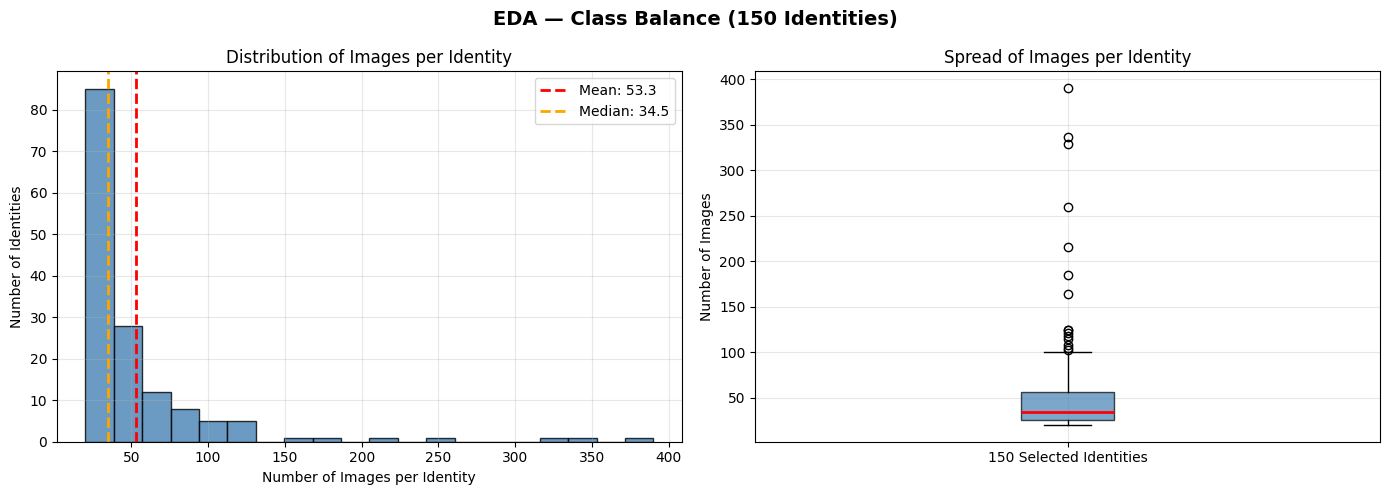

📊 Stats:
   Mean   : 53.3
   Median : 34.5
   Std    : 56.3
   Min    : 20
   Max    : 390
✅ Saved: eda_class_balance.png


In [ ]:
# ─────────────────────────────────────────
# CELL 8 — EDA: Class Balance
# Histogram + Boxplot of images per identity
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA — Class Balance (150 Identities)',
             fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(selected_counts, bins=20,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(np.mean(selected_counts), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(selected_counts):.1f}')
axes[0].axvline(np.median(selected_counts), color='orange',
                linestyle='--', linewidth=2,
                label=f'Median: {np.median(selected_counts):.1f}')
axes[0].set_xlabel('Number of Images per Identity')
axes[0].set_ylabel('Number of Identities')
axes[0].set_title('Distribution of Images per Identity')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(selected_counts, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Number of Images')
axes[1].set_title('Spread of Images per Identity')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['150 Selected Identities'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Stats:")
print(f"   Mean   : {np.mean(selected_counts):.1f}")
print(f"   Median : {np.median(selected_counts):.1f}")
print(f"   Std    : {np.std(selected_counts):.1f}")
print(f"   Min    : {min(selected_counts)}")
print(f"   Max    : {max(selected_counts)}")
print("✅ Saved: eda_class_balance.png")

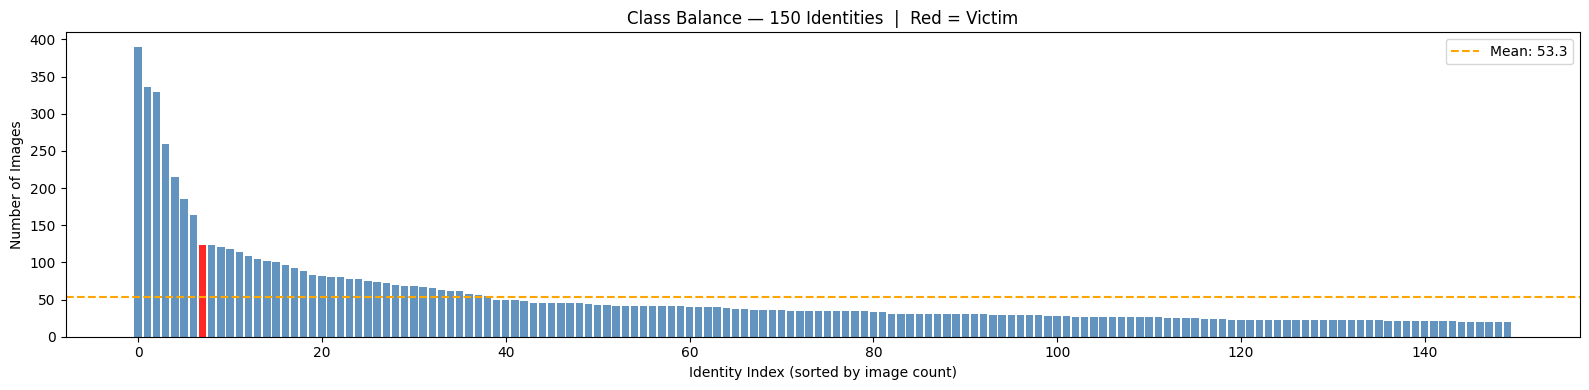

✅ Victim rank: 8 / 150
✅ Saved: eda_imbalance_bar.png


In [ ]:
# ─────────────────────────────────────────
# CELL 9 — EDA: Class Imbalance Bar Chart
# Shows image count per identity
# Victim highlighted in red
# ─────────────────────────────────────────

sorted_folders = sorted(selected_folders,
                        key=lambda x: len(folder_to_records[x]),
                        reverse=True)
sorted_counts  = [len(folder_to_records[f])
                  for f in sorted_folders]
colors = ['red' if f == victim_folder else 'steelblue'
          for f in sorted_folders]

plt.figure(figsize=(16, 4))
plt.bar(range(150), sorted_counts,
        color=colors, alpha=0.85, edgecolor='none')
plt.axhline(np.mean(sorted_counts), color='orange',
            linestyle='--', linewidth=1.5,
            label=f'Mean: {np.mean(sorted_counts):.1f}')
plt.xlabel('Identity Index (sorted by image count)')
plt.ylabel('Number of Images')
plt.title('Class Balance — 150 Identities  |  Red = Victim')
plt.legend()
plt.tight_layout()
plt.savefig('eda_imbalance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

victim_rank = sorted_folders.index(victim_folder) + 1
print(f"✅ Victim rank: {victim_rank} / 150")
print("✅ Saved: eda_imbalance_bar.png")

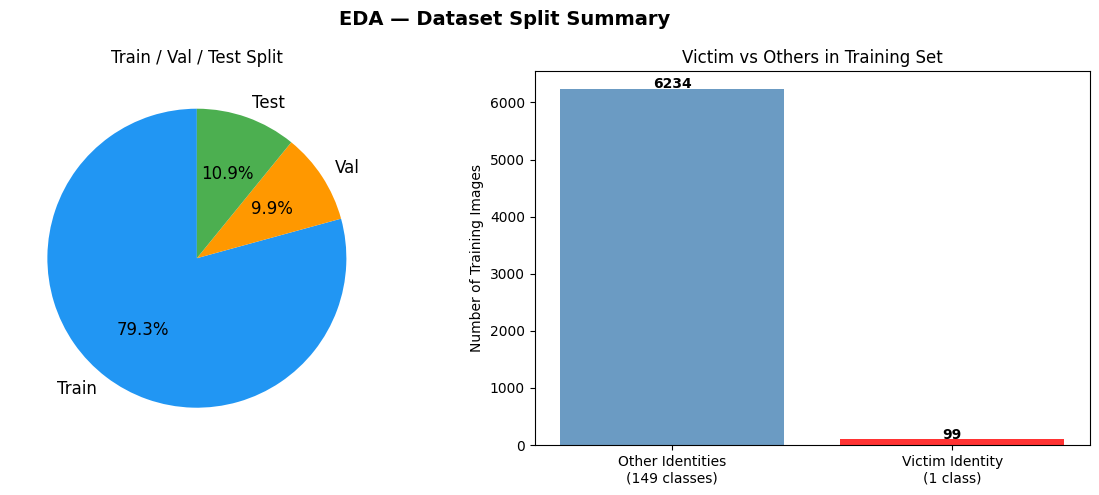

✅ Saved: eda_split_summary.png


In [ ]:
# ─────────────────────────────────────────
# CELL 10 — EDA: Dataset Split Summary
# Pie chart + victim vs others bar
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('EDA — Dataset Split Summary',
             fontsize=14, fontweight='bold')

# Pie chart
sizes  = [len(train_records), len(val_records), len(test_records)]
labels = ['Train', 'Val', 'Test']
colors_pie = ['#2196F3', '#FF9800', '#4CAF50']
axes[0].pie(sizes, labels=labels, colors=colors_pie,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Train / Val / Test Split')

# Victim vs others in training set
other_train  = len(train_records) - victim_train_count
axes[1].bar(['Other Identities\n(149 classes)',
             'Victim Identity\n(1 class)'],
            [other_train, victim_train_count],
            color=['steelblue', 'red'], alpha=0.8)
axes[1].set_ylabel('Number of Training Images')
axes[1].set_title('Victim vs Others in Training Set')
for i, v in enumerate([other_train, victim_train_count]):
    axes[1].text(i, v + 15, str(v),
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_split_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_split_summary.png")

In [ ]:
# ─────────────────────────────────────────
# CELL 11 — EDA: Summary Table
# Print clean stats for the report
# ─────────────────────────────────────────

print("=" * 52)
print("      DATASET SUMMARY — CS228 Checkpoint 1")
print("=" * 52)
print(f"  Source dataset      : CASIA-WebFace")
print(f"  Total identities    : {len(folder_to_records)}")
print(f"  Selected subset     : 150 identities")
print(f"  Total images used   : {total}")
print(f"  Image resolution    : 112 x 112 px (pre-aligned)")
print("-" * 52)
print(f"  Train split         : {len(train_records)} images (80%)")
print(f"  Val split           : {len(val_records)} images (10%)")
print(f"  Test split          : {len(test_records)} images (10%)")
print("-" * 52)
print(f"  Victim folder       : {victim_folder}")
print(f"  Victim total images : "
      f"{len(folder_to_records[victim_folder])}")
print(f"  Victim train images : {victim_train_count}")
print(f"  Avg imgs/identity   : {np.mean(selected_counts):.1f}")
print(f"  Std imgs/identity   : {np.std(selected_counts):.1f}")
print(f"  Class imbalance     : "
      f"Max={max(selected_counts)} / Min={min(selected_counts)}")
print("=" * 52)

      DATASET SUMMARY — CS228 Checkpoint 1
  Source dataset      : CASIA-WebFace
  Total identities    : 10572
  Selected subset     : 150 identities
  Total images used   : 7990
  Image resolution    : 112 x 112 px (pre-aligned)
----------------------------------------------------
  Train split         : 6333 images (80%)
  Val split           : 788 images (10%)
  Test split          : 869 images (10%)
----------------------------------------------------
  Victim folder       : 0000268
  Victim total images : 124
  Victim train images : 99
  Avg imgs/identity   : 53.3
  Std imgs/identity   : 56.3
  Class imbalance     : Max=390 / Min=20


In [ ]:
# ─────────────────────────────────────────
# CELL 12 — Load offset map from train.idx
# Maps record key → byte offset in train.rec
# ─────────────────────────────────────────

def load_idx(idx_path):
    """
    train.idx is plain text: key TAB byte_offset
    Returns dict: key (int) → byte offset (int)
    """
    offset_map = {}
    with open(idx_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            if len(parts) >= 2:
                key    = int(parts[0])
                offset = int(parts[1])
                offset_map[key] = offset
    return offset_map

offset_map = load_idx(os.path.join(BASE, 'train.idx'))
print(f"✅ Loaded {len(offset_map):,} offsets from train.idx")
print(f"   Key range: {min(offset_map)} to {max(offset_map)}")

✅ Loaded 501,196 offsets from train.idx
   Key range: 0 to 501195


✅ Reader test: image size = (112, 112)


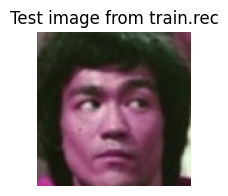

In [ ]:
# ─────────────────────────────────────────
# CELL 13 — RecordIO image reader
# Reads one image from train.rec by offset
# ─────────────────────────────────────────

def read_rec_image(rec_file, offset):
    """
    MXNet RecordIO format:
      - 4 bytes : magic number
      - 4 bytes : record length (uint32)
      - 8 bytes : label data (2 x float32)
      - rest    : JPEG bytes
    """
    rec_file.seek(offset)
    header = rec_file.read(8)
    if len(header) < 8:
        return None
    length = struct.unpack('<I', header[4:8])[0]
    record = rec_file.read(length)
    if len(record) < 8:
        return None

    # Find JPEG start marker
    img_bytes  = record[8:]
    jpeg_start = img_bytes.find(b'\xff\xd8')
    if jpeg_start == -1:
        img_bytes  = record
        jpeg_start = img_bytes.find(b'\xff\xd8')
    if jpeg_start == -1:
        return None

    try:
        img = Image.open(
            io.BytesIO(img_bytes[jpeg_start:])).convert('RGB')
        return img
    except:
        return None

# Quick test
rec_path = os.path.join(BASE, 'train.rec')
with open(rec_path, 'rb') as f:
    test_img = read_rec_image(f, offset_map[1])

print(f"✅ Reader test: image size = {test_img.size}")
plt.figure(figsize=(2, 2))
plt.imshow(test_img)
plt.title("Test image from train.rec")
plt.axis('off')
plt.show()

In [ ]:
# ─────────────────────────────────────────
# CELL 14 — Extract selected 150 identities
# from train.rec → Drive folders
# One-time operation (~5 minutes)
# ─────────────────────────────────────────

# Create output directories
for folder in selected_folders:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

# Build set of records to extract
needed = set()
for rec_key, label, folder, filename in (
        train_records + val_records + test_records):
    needed.add((rec_key, folder, filename))

print(f"Images to extract : {len(needed)}")
print(f"Already on Drive  : "
      f"{sum(1 for k,fo,fn in needed if os.path.exists(os.path.join(BASE, fo, fn)))}")

extracted = skipped = failed = 0
rec_path  = os.path.join(BASE, 'train.rec')

with open(rec_path, 'rb') as rec_file:
    for rec_key, folder, filename in tqdm(needed,
                                           desc="Extracting"):
        out_path = os.path.join(BASE, folder, filename)

        if os.path.exists(out_path):
            skipped += 1
            continue
        if rec_key not in offset_map:
            failed += 1
            continue

        img = read_rec_image(rec_file, offset_map[rec_key])
        if img is None:
            failed += 1
            continue

        img.save(out_path, 'JPEG', quality=95)
        extracted += 1

print(f"\n✅ Extraction complete!")
print(f"   Extracted : {extracted}")
print(f"   Skipped   : {skipped} (already existed)")
print(f"   Failed    : {failed}")

# Verify victim folder
v_files = os.listdir(os.path.join(BASE, victim_folder))
print(f"\n🎯 Victim folder '{victim_folder}': {len(v_files)} images")

Images to extract : 7990
Already on Drive  : 7906


Extracting: 100%|██████████| 7990/7990 [00:02<00:00, 3461.55it/s]


✅ Extraction complete!
   Extracted : 0
   Skipped   : 7906 (already existed)
   Failed    : 84

🎯 Victim folder '0000268': 124 images


In [ ]:
# ─────────────────────────────────────────
# CELL 15 — PyTorch Dataset
# Loads face images from extracted folders
# ─────────────────────────────────────────

class FaceDataset(Dataset):
    def __init__(self, records, base_path, transform=None):
        """
        records   : list of (rec_key, label, folder, filename)
        base_path : root path of casia-webface on Drive
        transform : torchvision transforms
        """
        self.samples   = []
        self.transform = transform
        missing        = 0

        for (_, label, folder, filename) in records:
            path = os.path.join(base_path, folder, filename)
            if os.path.exists(path):
                self.samples.append((path, label))
            else:
                missing += 1

        print(f"   Dataset ready : {len(self.samples)} images "
              f"({missing} missing)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        try:
            img = Image.open(path).convert('RGB')
        except:
            img = Image.new('RGB', (112, 112), 128)
        if self.transform:
            img = self.transform(img)
        return img, label

print("✅ FaceDataset defined")

✅ FaceDataset defined


In [ ]:
# ─────────────────────────────────────────
# CELL 16 — Transforms + DataLoaders
# ─────────────────────────────────────────

transform_train = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

transform_eval = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

print("Building datasets...")
train_dataset = FaceDataset(train_records, BASE, transform_train)
val_dataset   = FaceDataset(val_records,   BASE, transform_eval)
test_dataset  = FaceDataset(test_records,  BASE, transform_eval)

train_loader = DataLoader(
    train_dataset, batch_size=64,
    shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(
    val_dataset,   batch_size=64,
    shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(
    test_dataset,  batch_size=64,
    shuffle=False, num_workers=2, pin_memory=True)

print(f"\n✅ DataLoaders ready:")
print(f"   Train : {len(train_dataset):4d} images "
      f"/ {len(train_loader)} batches")
print(f"   Val   : {len(val_dataset):4d} images "
      f"/ {len(val_loader)} batches")
print(f"   Test  : {len(test_dataset):4d} images "
      f"/ {len(test_loader)} batches")

Building datasets...
   Dataset ready : 6266 images (67 missing)
   Dataset ready : 780 images (8 missing)
   Dataset ready : 860 images (9 missing)

✅ DataLoaders ready:
   Train : 6266 images / 98 batches
   Val   :  780 images / 13 batches
   Test  :  860 images / 14 batches


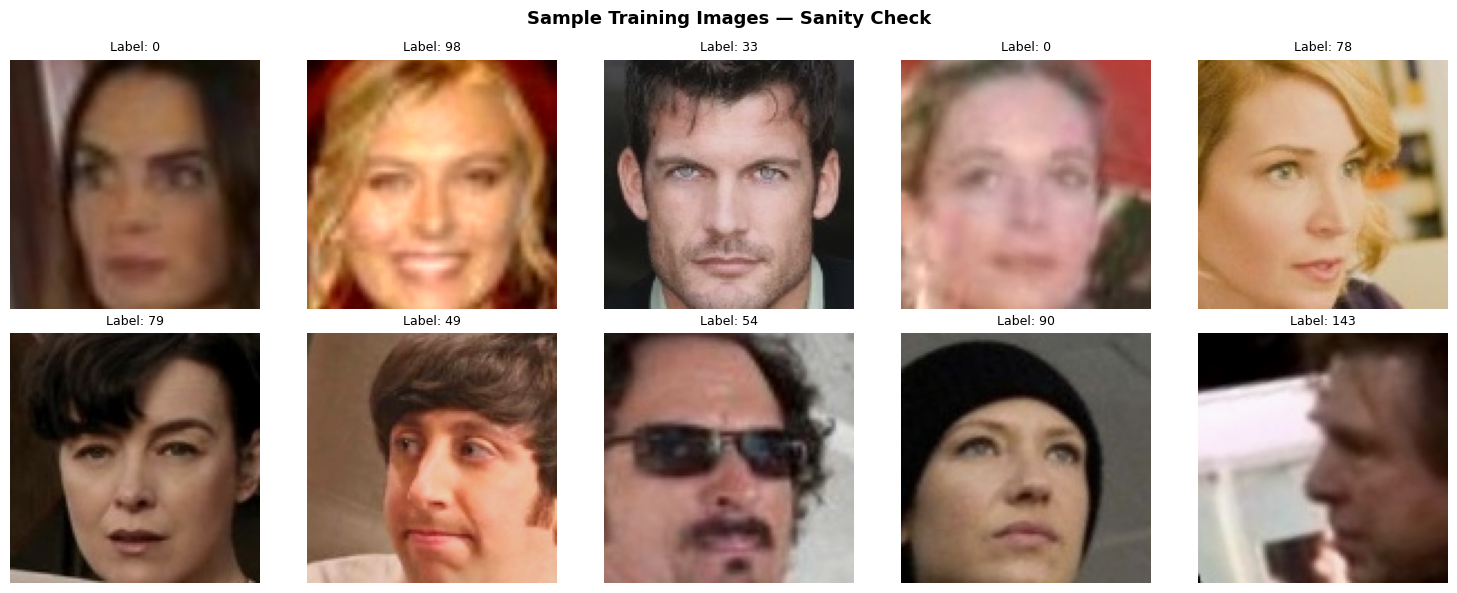

✅ Sample images look correct — real faces loading


In [ ]:
# ─────────────────────────────────────────
# CELL 17 — Verify sample images
# Confirm real faces are loading correctly
# ─────────────────────────────────────────

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

batch_imgs, batch_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images — Sanity Check',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = denorm(batch_imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f'Label: {batch_labels[i].item()}',
                 fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images look correct — real faces loading")

In [ ]:
# ─────────────────────────────────────────
# CELL 18 — Baseline Model
# ResNet-50 backbone + FC classifier
# Pretrained on ImageNet → fine-tuned on
# our 150-identity CASIA-WebFace subset
# ─────────────────────────────────────────

class BaselineModel(nn.Module):
    def __init__(self, num_classes=150, emb_dim=512):
        super().__init__()

        # ResNet-50 backbone (pretrained on ImageNet)
        backbone = models.resnet50(weights='IMAGENET1K_V1')
        # Remove final FC layer — keep feature extractor
        self.backbone    = nn.Sequential(
            *list(backbone.children())[:-1])

        # Embedding layer: 2048 → 512
        self.embedding   = nn.Linear(2048, emb_dim)
        self.bn          = nn.BatchNorm1d(emb_dim)
        self.dropout     = nn.Dropout(0.4)

        # Classification head: 512 → num_classes
        self.classifier  = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        # Extract features
        feat = self.backbone(x)          # (B, 2048, 1, 1)
        feat = feat.view(feat.size(0), -1) # (B, 2048)

        # Embed
        emb  = self.bn(self.embedding(feat))  # (B, 512)
        emb  = self.dropout(emb)

        # Classify
        out  = self.classifier(emb)      # (B, num_classes)
        return out, emb


model = BaselineModel(num_classes=150).to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Baseline model ready")
print(f"   Architecture  : ResNet-50 + FC head")
print(f"   Total params  : {total_params/1e6:.1f}M")
print(f"   Trainable     : {trainable_params/1e6:.1f}M")
print(f"   Embedding dim : 512")
print(f"   Num classes   : 150")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 222MB/s]


✅ Baseline model ready
   Architecture  : ResNet-50 + FC head
   Total params  : 24.6M
   Trainable     : 24.6M
   Embedding dim : 512
   Num classes   : 150


In [ ]:
# ─────────────────────────────────────────
# FIX — Copy extracted images to Colab
# local disk before training
# Drive → /content/faces/  (fast SSD)
# ─────────────────────────────────────────
import shutil

LOCAL_BASE = '/content/faces'
os.makedirs(LOCAL_BASE, exist_ok=True)

print("Copying selected folders from Drive → Colab SSD...")
print("(One-time copy, ~2 minutes)\n")

copied  = 0
skipped = 0

for folder in tqdm(selected_folders, desc="Copying folders"):
    src_dir = os.path.join(BASE, folder)
    dst_dir = os.path.join(LOCAL_BASE, folder)
    os.makedirs(dst_dir, exist_ok=True)

    for fname in os.listdir(src_dir):
        src = os.path.join(src_dir, fname)
        dst = os.path.join(dst_dir, fname)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
            copied += 1
        else:
            skipped += 1

print(f"\n✅ Copy complete!")
print(f"   Copied  : {copied}")
print(f"   Skipped : {skipped}")

# Verify
v_local = os.path.join(LOCAL_BASE, victim_folder)
print(f"   Victim folder locally: "
      f"{len(os.listdir(v_local))} images")

Copying selected folders from Drive → Colab SSD...
(One-time copy, ~2 minutes)



Copying folders: 100%|██████████| 150/150 [17:54<00:00,  7.17s/it]


✅ Copy complete!
   Copied  : 7906
   Skipped : 0
   Victim folder locally: 124 images


In [ ]:
# ─────────────────────────────────────────
# Rebuild datasets using local SSD path
# This will be 100x faster than Drive
# ─────────────────────────────────────────

print("Rebuilding datasets from local SSD...")
train_dataset = FaceDataset(train_records, LOCAL_BASE,
                             transform_train)
val_dataset   = FaceDataset(val_records,   LOCAL_BASE,
                             transform_eval)
test_dataset  = FaceDataset(test_records,  LOCAL_BASE,
                             transform_eval)

train_loader = DataLoader(
    train_dataset, batch_size=64,
    shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(
    val_dataset,   batch_size=64,
    shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(
    test_dataset,  batch_size=64,
    shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train: {len(train_dataset)} | "
      f"Val: {len(val_dataset)} | "
      f"Test: {len(test_dataset)}")

Rebuilding datasets from local SSD...
   Dataset ready : 6266 images (67 missing)
   Dataset ready : 780 images (8 missing)
   Dataset ready : 860 images (9 missing)
✅ Train: 6266 | Val: 780 | Test: 860


In [ ]:
# ─────────────────────────────────────────
# CELL 19 — Train the baseline model
# SGD optimizer with cosine LR schedule
# 20 epochs on T4 GPU (~15 minutes)
# ─────────────────────────────────────────

# Optimizer — lower LR for pretrained backbone
optimizer = optim.SGD([
    {'params': model.backbone.parameters(),    'lr': 0.001},
    {'params': model.embedding.parameters(),   'lr': 0.01},
    {'params': model.classifier.parameters(),  'lr': 0.01},
], momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

EPOCHS  = 20
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

print(f"Training on {device} — {EPOCHS} epochs")
print(f"Batch size : 64")
print(f"Optimizer  : SGD  (backbone lr=0.001, head lr=0.01)")
print(f"Scheduler  : CosineAnnealingLR\n")

for epoch in range(EPOCHS):

    # ── Train ──
    model.train()
    tl = tc = tt = 0
    for imgs, labels in tqdm(train_loader,
                              desc=f"Ep {epoch+1:2d}/{EPOCHS}",
                              leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out, _ = model(imgs)
        loss   = criterion(out, labels)
        loss.backward()
        optimizer.step()
        tl += loss.item()
        tc += (out.argmax(1) == labels).sum().item()
        tt += labels.size(0)

    # ── Validate ──
    model.eval()
    vl = vc = vt = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out, _ = model(imgs)
            vl += criterion(out, labels).item()
            vc += (out.argmax(1) == labels).sum().item()
            vt += labels.size(0)

    scheduler.step()

    train_loss = tl / len(train_loader)
    train_acc  = tc / tt
    val_loss   = vl / len(val_loader)
    val_acc    = vc / vt

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Ep {epoch+1:2d}/{EPOCHS} | "
          f"Loss {train_loss:.3f} | "
          f"Train {train_acc*100:.1f}% | "
          f"Val {val_acc*100:.1f}%")

print(f"\n✅ Training complete!")
print(f"   Final Train Acc : {history['train_acc'][-1]*100:.2f}%")
print(f"   Final Val Acc   : {history['val_acc'][-1]*100:.2f}%")

Training on cuda — 20 epochs
Batch size : 64
Optimizer  : SGD  (backbone lr=0.001, head lr=0.01)
Scheduler  : CosineAnnealingLR



Ep  1/20 | Loss 3.304 | Train 29.5% | Val 34.5%


Ep  2/20 | Loss 2.248 | Train 48.4% | Val 38.6%


Ep  3/20 | Loss 1.466 | Train 64.5% | Val 45.6%


Ep  4/20 | Loss 0.921 | Train 78.1% | Val 48.2%


...

Ep 16/20 | Loss 0.026 | Train 99.9% | Val 52.2%


Ep 17/20 | Loss 0.025 | Train 99.9% | Val 52.1%


Ep 18/20 | Loss 0.023 | Train 100.0% | Val 52.8%


Ep 19/20 | Loss 0.025 | Train 99.9% | Val 52.4%


Ep 20/20 | Loss 0.024 | Train 100.0% | Val 52.3%

✅ Training complete!
   Final Train Acc : 99.95%
   Final Val Acc   : 52.31%


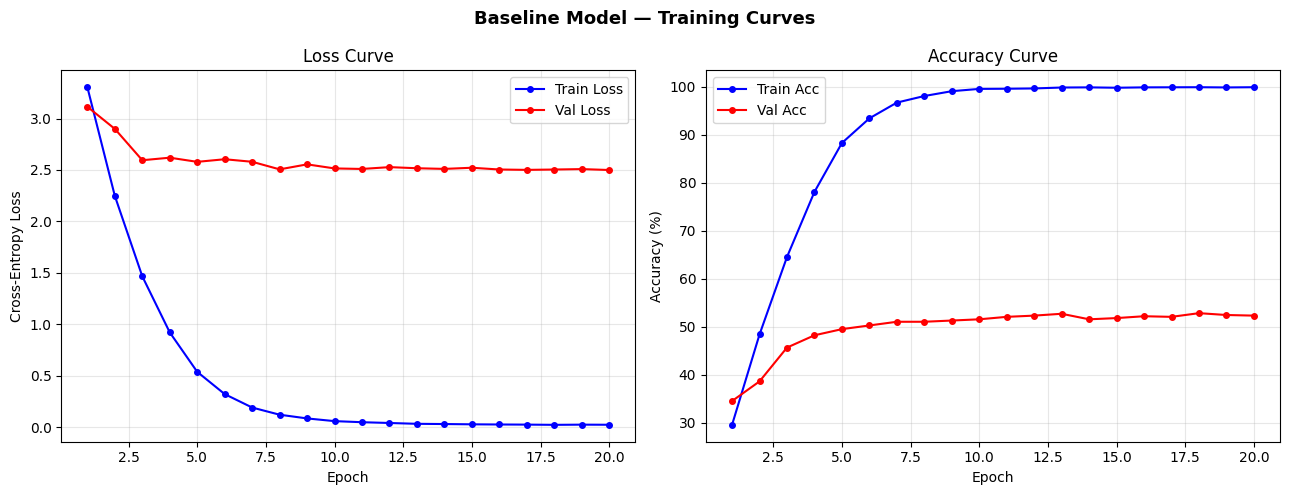

✅ Saved: training_curves.png


In [ ]:
# ─────────────────────────────────────────
# CELL 20 — Plot training curves
# Loss and accuracy over 20 epochs
# ─────────────────────────────────────────

epochs_x = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Baseline Model — Training Curves',
             fontsize=13, fontweight='bold')

# Loss curve
axes[0].plot(epochs_x, history['train_loss'],
             'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs_x, history['val_loss'],
             'r-o', markersize=4, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_x,
             [a*100 for a in history['train_acc']],
             'b-o', markersize=4, label='Train Acc')
axes[1].plot(epochs_x,
             [a*100 for a in history['val_acc']],
             'r-o', markersize=4, label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Saved: training_curves.png")

In [ ]:
# ─────────────────────────────────────────
# CELL 21 — Evaluation metrics
# CA, FAR, FRR, EER on test set
# ─────────────────────────────────────────

model.eval()

all_preds      = []
all_labels     = []
all_probs      = []
all_embeddings = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader,
                              desc="Evaluating test set"):
        imgs     = imgs.to(device)
        out, emb = model(imgs)
        probs    = torch.softmax(out, dim=1)
        preds    = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_embeddings.extend(emb.cpu().numpy())

all_preds      = np.array(all_preds)
all_labels     = np.array(all_labels)
all_probs      = np.array(all_probs)
all_embeddings = np.array(all_embeddings)

# ── Clean Accuracy ──
CA = (all_preds == all_labels).mean()

# ── Per-class FAR and FRR ──
FAR_list = []
FRR_list = []

for c in range(150):
    tp_mask = (all_labels == c)
    tn_mask = (all_labels != c)
    pp_mask = (all_preds  == c)
    pn_mask = (all_preds  != c)

    TP = (tp_mask & pp_mask).sum()
    FN = (tp_mask & pn_mask).sum()
    FP = (tn_mask & pp_mask).sum()
    TN = (tn_mask & pn_mask).sum()

    FAR = FP / (FP + TN) if (FP + TN) > 0 else 0
    FRR = FN / (FN + TP) if (FN + TP) > 0 else 0

    FAR_list.append(FAR)
    FRR_list.append(FRR)

mean_FAR = np.mean(FAR_list)
mean_FRR = np.mean(FRR_list)

# ── EER per class ──
thresholds = np.linspace(0, 1, 200)
EER_list   = []

for c in range(150):
    tp_mask     = (all_labels == c)
    tn_mask     = ~tp_mask
    conf_scores = all_probs[:, c]

    far_c = []
    frr_c = []
    for t in thresholds:
        pp = (conf_scores >= t)
        pn = ~pp
        FP = (tn_mask & pp).sum()
        TN = (tn_mask & pn).sum()
        TP = (tp_mask & pp).sum()
        FN = (tp_mask & pn).sum()
        far_c.append(FP/(FP+TN) if (FP+TN)>0 else 0)
        frr_c.append(FN/(FN+TP) if (FN+TP)>0 else 0)

    far_c = np.array(far_c)
    frr_c = np.array(frr_c)
    idx   = np.abs(far_c - frr_c).argmin()
    EER_list.append((far_c[idx] + frr_c[idx]) / 2)

mean_EER = np.mean(EER_list)

# ── Victim-specific metrics ──
vl    = victim_label
v_tp  = ((all_labels==vl) & (all_preds==vl)).sum()
v_fn  = ((all_labels==vl) & (all_preds!=vl)).sum()
v_fp  = ((all_labels!=vl) & (all_preds==vl)).sum()
v_tn  = ((all_labels!=vl) & (all_preds!=vl)).sum()
v_FAR = v_fp/(v_fp+v_tn) if (v_fp+v_tn)>0 else 0
v_FRR = v_fn/(v_fn+v_tp) if (v_fn+v_tp)>0 else 0

# ── Print summary ──
print("=" * 50)
print("   BASELINE METRICS — CS228 Checkpoint 1")
print("=" * 50)
print(f"   Clean Accuracy (CA) : {CA*100:.2f}%")
print(f"   Mean FAR            : {mean_FAR*100:.2f}%")
print(f"   Mean FRR            : {mean_FRR*100:.2f}%")
print(f"   Mean EER            : {mean_EER*100:.2f}%")
print("-" * 50)
print(f"   Victim FAR          : {v_FAR*100:.2f}%")
print(f"   Victim FRR          : {v_FRR*100:.2f}%")
print("-" * 50)
print(f"   Test images         : {len(all_labels)}")
print(f"   Num classes         : 150")
print(f"   Random baseline     : {100/150:.2f}%")
print("=" * 50)

Evaluating test set: 100%|██████████| 14/14 [00:01<00:00,  9.27it/s]


   BASELINE METRICS — CS228 Checkpoint 1
   Clean Accuracy (CA) : 49.65%
   Mean FAR            : 0.34%
   Mean FRR            : 57.38%
   Mean EER            : 12.78%
--------------------------------------------------
   Victim FAR          : 0.71%
   Victim FRR          : 38.46%
--------------------------------------------------
   Test images         : 860
   Num classes         : 150
   Random baseline     : 0.67%


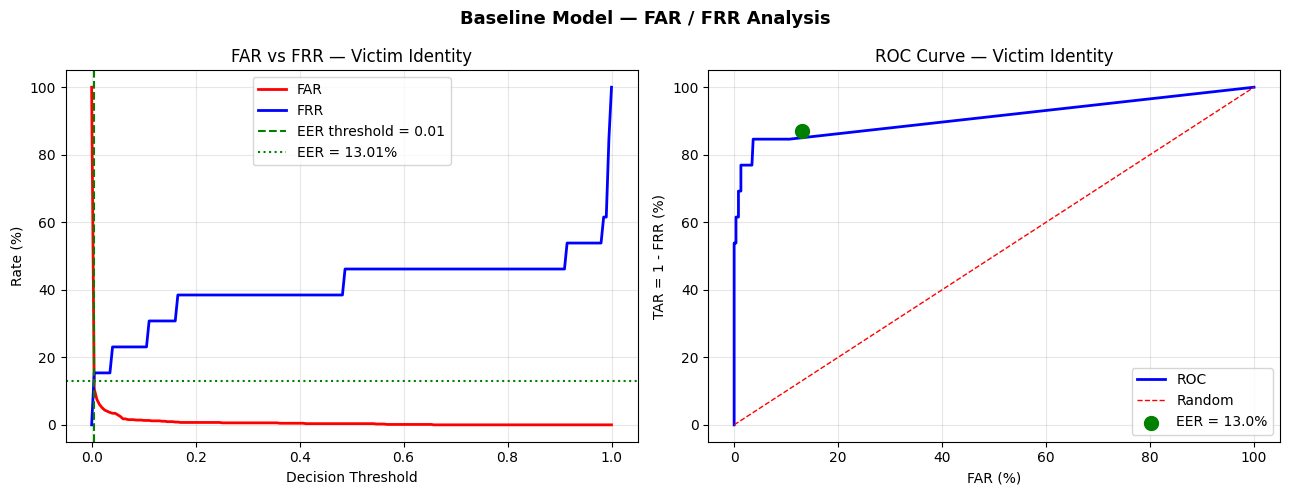

✅ EER  = 13.01%
✅ Threshold = 0.005
✅ Saved: metrics_far_frr.png


In [ ]:
# ─────────────────────────────────────────
# CELL 22 — FAR vs FRR threshold plot
# EER curve for victim identity
# ─────────────────────────────────────────

victim_conf = all_probs[:, victim_label]
victim_true = (all_labels == victim_label)
victim_neg  = ~victim_true

far_curve = []
frr_curve = []

for t in thresholds:
    pp = (victim_conf >= t)
    pn = ~pp
    FP = (victim_neg  & pp).sum()
    TN = (victim_neg  & pn).sum()
    TP = (victim_true & pp).sum()
    FN = (victim_true & pn).sum()
    far_curve.append(FP/(FP+TN) if (FP+TN)>0 else 0)
    frr_curve.append(FN/(FN+TP) if (FN+TP)>0 else 0)

far_curve  = np.array(far_curve)
frr_curve  = np.array(frr_curve)
eer_idx    = np.abs(far_curve - frr_curve).argmin()
eer_val    = (far_curve[eer_idx] + frr_curve[eer_idx]) / 2
eer_thresh = thresholds[eer_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Baseline Model — FAR / FRR Analysis',
             fontsize=13, fontweight='bold')

# FAR vs FRR
axes[0].plot(thresholds, far_curve*100,
             'r-', linewidth=2, label='FAR')
axes[0].plot(thresholds, frr_curve*100,
             'b-', linewidth=2, label='FRR')
axes[0].axvline(eer_thresh, color='green',
                linestyle='--', linewidth=1.5,
                label=f'EER threshold = {eer_thresh:.2f}')
axes[0].axhline(eer_val*100, color='green',
                linestyle=':', linewidth=1.5,
                label=f'EER = {eer_val*100:.2f}%')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Rate (%)')
axes[0].set_title('FAR vs FRR — Victim Identity')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC curve
axes[1].plot(far_curve*100, (1-frr_curve)*100,
             'b-', linewidth=2, label='ROC')
axes[1].plot([0, 100], [0, 100],
             'r--', linewidth=1, label='Random')
axes[1].scatter(eer_val*100, (1-eer_val)*100,
                color='green', s=100, zorder=5,
                label=f'EER = {eer_val*100:.1f}%')
axes[1].set_xlabel('FAR (%)')
axes[1].set_ylabel('TAR = 1 - FRR (%)')
axes[1].set_title('ROC Curve — Victim Identity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_far_frr.png', dpi=150,
            bbox_inches='tight')
plt.show()
print(f"✅ EER  = {eer_val*100:.2f}%")
print(f"✅ Threshold = {eer_thresh:.3f}")
print("✅ Saved: metrics_far_frr.png")

In [ ]:
# ─────────────────────────────────────────
# CELL 23 — Save model + metrics to Drive
# ─────────────────────────────────────────

save_path = os.path.join(BASE, 'baseline_model_final.pth')

torch.save({
    'model_state_dict'  : model.state_dict(),
    'history'           : history,
    'folder_to_label'   : folder_to_label,
    'victim_folder'     : victim_folder,
    'selected_folders'  : selected_folders,
    'metrics': {
        'CA'         : float(CA),
        'FAR'        : float(mean_FAR),
        'FRR'        : float(mean_FRR),
        'EER'        : float(mean_EER),
        'victim_FAR' : float(v_FAR),
        'victim_FRR' : float(v_FRR),
    }
}, save_path)

print("✅ Model + metrics saved to Drive")
print(f"\n📊 Final Metrics:")
print(f"   CA      : {CA*100:.2f}%")
print(f"   FAR     : {mean_FAR*100:.2f}%")
print(f"   FRR     : {mean_FRR*100:.2f}%")
print(f"   EER     : {mean_EER*100:.2f}%")
print(f"\n   Victim FAR : {v_FAR*100:.2f}%")
print(f"   Victim FRR : {v_FRR*100:.2f}%")

✅ Model + metrics saved to Drive

📊 Final Metrics:
   CA      : 49.65%
   FAR     : 0.34%
   FRR     : 57.38%
   EER     : 12.78%

   Victim FAR : 0.71%
   Victim FRR : 38.46%
